In [70]:
import torch
import torch.nn as nn
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [71]:

path1 = kagglehub.dataset_download("novandraanugrah/bitcoin-historical-datasets-2018-2024")

print("The dataset is downloaded to:", path1)

files1 = os.listdir(path1)
print("Folder contents:", files1)

The dataset is downloaded to: C:\Users\mmapa\.cache\kagglehub\datasets\novandraanugrah\bitcoin-historical-datasets-2018-2024\versions\419
Folder contents: ['btc_15m_data_2018_to_2025.csv', 'btc_1d_data_2018_to_2025.csv', 'btc_1h_data_2018_to_2025.csv', 'btc_4h_data_2018_to_2025.csv']


In [72]:
bitcoin = pd.read_csv(os.path.join(path1, "btc_1d_data_2018_to_2025.csv"))

In [73]:
bitcoin.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [74]:
bitcoin.tail()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
2984,2026-03-04 00:00:00.000000 UTC,68338.01,68909.34,67857.61,68543.03,1831.35805,2026-03-04 23:59:59.999000 UTC,1.250343e+08,501562,913.83373,6.242022e+07,0
2985,2026-03-05 00:00:00.000000 UTC,72666.77,73306.82,72553.65,72589.46,1646.99020,2026-03-05 23:59:59.999000 UTC,1.199628e+08,504466,801.89199,5.841682e+07,0
2986,2026-03-06 00:00:00.000000 UTC,70891.02,71261.29,70344.03,71152.82,1651.57947,2026-03-06 23:59:59.999000 UTC,1.170352e+08,412082,864.12652,6.126500e+07,0
2987,2026-03-07 00:00:00.000000 UTC,68114.02,68394.09,68105.73,68251.56,914.93110,2026-03-07 23:59:59.999000 UTC,6.241224e+07,138700,463.00624,3.158072e+07,0
2988,2026-03-08 00:00:00.000000 UTC,67262.91,67481.96,67090.00,67329.41,1095.93084,2026-03-08 23:59:59.999000 UTC,7.372613e+07,142092,656.49587,4.415627e+07,0


In [75]:
bitcoin_close = bitcoin[['Close time', 'Close']]


In [76]:
bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])
#move to datetime

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\2044088185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = pd.to_datetime(bitcoin_close['Close time'])


In [77]:
bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date
# move to date

C:\Users\mmapa\AppData\Local\Temp\ipykernel_27344\4100889944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bitcoin_close['Close time'] = bitcoin_close['Close time'].dt.date


In [78]:
bitcoin_close = bitcoin_close.set_index('Close time')
bitcoin_close.index = pd.to_datetime(bitcoin_close.index)# this is important, it fixes the index

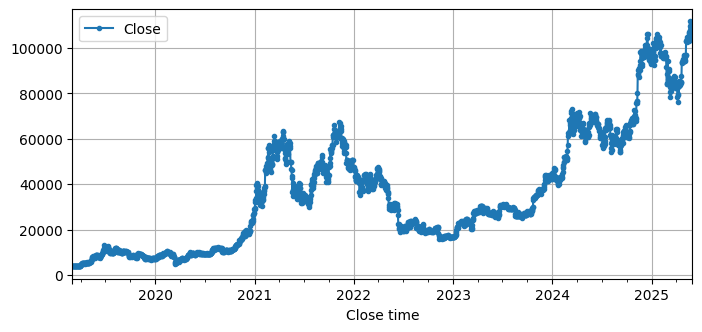

In [79]:
bitcoin_close["2019-03":"2025-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

In [95]:
from torch.utils.data import DataLoader
btc_train = torch.FloatTensor(bitcoin_close[['Close']]["2018-01":"2024-12"].values)
btc_valid = torch.FloatTensor(bitcoin_close[['Close']]["2025-01":"2025-06"].values)
btc_test = torch.FloatTensor(bitcoin_close[['Close']]["2025-07":].values)


In [81]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end] # wszystkie wartosci "okna"
        target = self.series[end] #wartosc po oknie
        return window, target

In [97]:
window_length = 56
train_set = TimeSeriesDataset(btc_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=False)
valid_set = TimeSeriesDataset(btc_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
test_set = TimeSeriesDataset(btc_test, window_length)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [83]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [84]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

linear model

In [98]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=150)

Epoch 1/150, train loss: 64012928.0222, train metric: 5046.8511, valid metric: 10059.0977
Epoch 2/150, train loss: 58680309.9763, train metric: 5631.2466, valid metric: 8946.0283
Epoch 3/150, train loss: 38169024.1250, train metric: 4436.9741, valid metric: 7562.9702
Epoch 4/150, train loss: 26106774.2405, train metric: 3581.3059, valid metric: 6320.8926
Epoch 5/150, train loss: 18363054.5680, train metric: 2896.8445, valid metric: 5356.4600
Epoch 6/150, train loss: 13822274.2652, train metric: 2411.3381, valid metric: 4668.6519
Epoch 7/150, train loss: 11051148.1481, train metric: 2052.0398, valid metric: 4236.6938
Epoch 8/150, train loss: 9522641.5674, train metric: 1843.2317, valid metric: 3937.5190
Epoch 9/150, train loss: 8864769.2450, train metric: 1815.8695, valid metric: 3672.4375
Epoch 10/150, train loss: 8748735.2241, train metric: 1889.3705, valid metric: 3398.0569
Epoch 11/150, train loss: 8781097.7009, train metric: 1975.7981, valid metric: 3156.8159
Epoch 12/150, train lo

In [ ]:
evaluate_tm(model, valid_loader, metric)

tensor(0.0216)

In [87]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])
    #-1 is the last output, we want to predict the next value after the window
    # always batch size, sequence length, features(input size)

In [88]:
def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=150,
                     patience=20, factor=0.1):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"])

In [90]:
torch.manual_seed(42)
deep_model = DeepRnnModel(
    input_size=1, hidden_size=32, output_size=1, num_layers=3).to(device)
fit_and_evaluate(deep_model, train_loader, valid_loader, lr=0.27, n_epochs=150)

Epoch 1/150, train loss: 1354348487.4557, train metric: 28083.4395, valid metric: 94170.8516
Epoch 2/150, train loss: 1317860200.3544, train metric: 27388.2734, valid metric: 93583.3125
Epoch 3/150, train loss: 1286245029.8734, train metric: 26813.6855, valid metric: 93024.4609
Epoch 4/150, train loss: 1256371527.1930, train metric: 26261.9727, valid metric: 92481.2578
Epoch 5/150, train loss: 1227797123.0403, train metric: 25724.2090, valid metric: 91949.6484
Epoch 6/150, train loss: 1200343172.0388, train metric: 25197.3105, valid metric: 91427.8594
Epoch 7/150, train loss: 1173910401.9367, train metric: 24684.7891, valid metric: 90914.8594
Epoch 8/150, train loss: 1148432454.5183, train metric: 24211.0918, valid metric: 90410.0781
Epoch 9/150, train loss: 1123859681.3734, train metric: 23762.3535, valid metric: 89913.0859
Epoch 10/150, train loss: 1100151712.7951, train metric: 23323.7637, valid metric: 89423.5938
Epoch 11/150, train loss: 1077274076.1725, train metric: 22902.1660, 

66238.5